In [1]:
import sqlite3
import os
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from itertools import combinations
import re

spark = SparkSession.builder.appName("FrequentItemsetMining").getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/16 17:27:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
conn = sqlite3.connect('tiktok_breadth_first.db')
cursor = conn.cursor()

In [3]:
query = """ 
SELECT hashtag_names 
FROM videos
JOIN follow_relations
ON follow_relations.from_username = videos.reposter_username
WHERE follow_relations.to_username = 'kamalahq'
"""

k_data = cursor.execute(query).fetchall()

In [4]:
query = """ 
SELECT hashtag_names 
FROM videos
JOIN follow_relations
ON follow_relations.from_username = videos.reposter_username
WHERE follow_relations.to_username = 'teamtrump'
"""

t_data = cursor.execute(query).fetchall()

In [5]:
k_df = spark.createDataFrame(k_data, ['raw_hash'])
t_df = spark.createDataFrame(t_data, ['raw_hash'])

In [6]:
k_df.show(5)

26/01/16 17:27:36 WARN TaskSetManager: Stage 0 contains a task of very large size (1758 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+
|            raw_hash|
+--------------------+
|                 fyp|
|blancaevangelista...|
|foryou,Sleep,bedt...|
|cardsagainsthuman...|
|                    |
+--------------------+
only showing top 5 rows



In [7]:
# Spark-native hashtag preprocessing: split by commas, remove non-alphanumerics, lowercase, drop 'fyp'
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Use existing DataFrame `k_df` and ensure `raw_hash` is a string without nulls
_df = k_df.withColumn("raw_hash", F.coalesce(F.col("raw_hash").cast("string"), F.lit("")))

# Remove any characters except letters, digits, and commas
_cleaned = F.regexp_replace(F.col("raw_hash"), r"[^a-zA-Z0-9,]+", "")
_tokens = F.split(_cleaned, ",")

# Lowercase and filter out empty strings and 'fyp'
_lowered = F.transform(_tokens, lambda x: F.lower(x))
_filtered = F.filter(_lowered, lambda x: (x != "") & (x != "fyp"))

# Add the cleaned list and a sequential id
w = Window.orderBy(F.monotonically_increasing_id())
k_df_clean = (
    _df
    .withColumn("clean_hash", _filtered)
    .withColumn("id", F.row_number().over(w))
)

_df = t_df.withColumn("raw_hash", F.coalesce(F.col("raw_hash").cast("string"), F.lit("")))

# Remove any characters except letters, digits, and commas
_cleaned = F.regexp_replace(F.col("raw_hash"), r"[^a-zA-Z0-9,]+", "")
_tokens = F.split(_cleaned, ",")

# Lowercase and filter out empty strings and 'fyp'
_lowered = F.transform(_tokens, lambda x: F.lower(x))
_filtered = F.filter(_lowered, lambda x: (x != "") & (x != "fyp"))

# Add the cleaned list and a sequential id
w = Window.orderBy(F.monotonically_increasing_id())
t_df_clean = (
    _df
    .withColumn("clean_hash", _filtered)
    .withColumn("id", F.row_number().over(w))
)

# Show sample
t_df_clean.select("id", "raw_hash", "clean_hash").show(5, truncate=False)

26/01/16 17:27:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:38 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---+-------------------------------------------------------------+-------------------------------------------------------------------+
|id |raw_hash                                                     |clean_hash                                                         |
+---+-------------------------------------------------------------+-------------------------------------------------------------------+
|1  |overtime,fyp,trump2024                                       |[overtime, trump2024]                                              |
|2  |electrician,fyp,Viral                                        |[electrician, viral]                                               |
|3  |fy,construction,bluecollar,heat                              |[fy, construction, bluecollar, heat]                               |
|4  |fyp                                                          |[]                                                                 |
|5  |mgplumbing,TaylorSwift,dallastx,plumbersoft

In [8]:
k_df = k_df_clean.select('id', 'clean_hash')
t_df = t_df_clean.select('id', 'clean_hash')

In [9]:
def preprocess(x):
    """
    preprocessing strings with hashtags. commas are delimiters.
    need to filter out non-alphanumeric symbols

    IMPORTANT: filters out 'fyp' from list of hashtags
    """
    index = 0
    for row in x:
        index += 1
        hash_list = []
        rough_list = re.split(',', row['raw_hash'])
        for hash in rough_list:
            match_alphanum = re.findall(r'[a-zA-Z0-9]+', hash)
            for x in match_alphanum:
                if x.lower() != 'fyp':
                    hash_list.append(x.lower())
        row['id'] = index
        row['clean_hash'] = hash_list
        yield row

In [10]:
k_df.show(5)

26/01/16 17:27:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:40 WARN TaskSetManager: Stage 3 contains a task of very large size (1758 KiB). The maximum recommended task size is 1000 KiB.


+---+--------------------+
| id|          clean_hash|
+---+--------------------+
|  1|                  []|
|  2|[blancaevangelist...|
|  3|[foryou, sleep, b...|
|  4|[cardsagainsthuma...|
|  5|                  []|
+---+--------------------+
only showing top 5 rows



In [11]:
t_df.show(5)

26/01/16 17:27:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:27:43 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+---+--------------------+
| id|          clean_hash|
+---+--------------------+
|  1|[overtime, trump2...|
|  2|[electrician, viral]|
|  3|[fy, construction...|
|  4|                  []|
|  5|[mgplumbing, tayl...|
+---+--------------------+
only showing top 5 rows



In [23]:
# support: minimum number s of posts an item needs to show up in
s_kamala = k_df.count() * 0.0025
L1 = (
    k_df.rdd.flatMap(lambda row: [((item,), 1) for item in row.clean_hash])
    .reduceByKey(lambda x, y: x + y)
    .filter(lambda x: x[1] >= s_kamala)
    .collect()
)

Lk_1_kamala = (dict(L1))

26/01/16 17:31:33 WARN TaskSetManager: Stage 51 contains a task of very large size (1758 KiB). The maximum recommended task size is 1000 KiB.


In [24]:
s_trump = t_df.count() * 0.0025

L1 = (
    t_df.rdd.flatMap(lambda row: [((item,), 1) for item in row.clean_hash])
    .reduceByKey(lambda x, y: x + y)
    .filter(lambda x: x[1] >= s_trump)
    .collect()
)

Lk_1_trump = (dict(L1))

In [25]:
Lk_1_kamala = {k: v for k, v in sorted(Lk_1_kamala.items(), key=lambda item: item[1], reverse=True)}
Lk_1_trump = {k: v for k, v in sorted(Lk_1_trump.items(), key=lambda item: item[1], reverse=True)}  

In [26]:
for item, count in Lk_1_trump.items():
    print(f"{item}: {count}")

('viral',): 23311
('foryou',): 12105
('foryoupage',): 10895
('edit',): 10359
('relatable',): 7337
('funny',): 6545
('trending',): 4823
('real',): 3736
('fypviral',): 3714
('fy',): 3637
('anime',): 3536
('xyzbca',): 3528
('meme',): 3037
('capcut',): 2868
('viralvideo',): 2496
('blowthisup',): 2398
('fyppppppppppppppppppppppp',): 2392
('tiktok',): 2161
('trend',): 2102
('fypage',): 2045
('animeedit',): 1882
('fortnite',): 1576
('goviral',): 1552
('genx',): 1552
('nostalgia',): 1526
('love',): 1523
('bleach',): 1446
('cat',): 1410
('football',): 1311
('ufc',): 1309
('cars',): 1246
('roblox',): 1227
('music',): 1209
('gaming',): 1170
('blowup',): 1138
('christmas',): 1127
('motivation',): 1092
('school',): 1080
('dc',): 1070
('catsoftiktok',): 1070
('minecraft',): 1056
('dexter',): 1003
('mma',): 947
('jujutsukaisen',): 927
('strangerthings',): 915
('pourtoi',): 905
('carsoftiktok',): 898
('jjk',): 882
('r6',): 867
('doctorwho',): 867
('usa',): 865
('bro',): 862
('sad',): 845
('gym',): 843

In [27]:
for item, count in Lk_1_kamala.items():
    print(f"{item}: {count}")

('viral',): 105241
('foryoupage',): 63916
('foryou',): 61782
('relatable',): 42341
('edit',): 41038
('funny',): 28729
('xyzbca',): 24949
('trending',): 23755
('billieeilish',): 21557
('fypviral',): 19448
('fy',): 15515
('fyppppppppppppppppppppppp',): 14021
('real',): 12986
('trend',): 12636
('blowthisup',): 12074
('viralvideo',): 11523
('fypage',): 11495
('meme',): 10759
('strangerthings',): 9878
('roblox',): 8877
('capcut',): 7986
('billieeilishedits',): 7812
('blowup',): 7786
('school',): 7738
('tiktok',): 7634
('music',): 7067
('wlw',): 6738
('goviral',): 6627
('katseye',): 6304
('kpop',): 6292
('aftereffects',): 6156
('anime',): 5829
('xybca',): 5705
('edits',): 5316
('nostalgia',): 5275
('love',): 5123
('cat',): 4752
('strangerthings5',): 4623
('fypp',): 4536
('lyrics',): 4507
('billie',): 4335
('xyzabc',): 4300
('christmas',): 4291
('aesthetic',): 4041
('fyppp',): 4026
('relateable',): 3906
('squidgame',): 3868
('hmhas',): 3840
('makemefamous',): 3800
('halloween',): 3783
('sad',

26/01/16 17:58:58 WARN TaskSetManager: Stage 177 contains a task of very large size (1758 KiB). The maximum recommended task size is 1000 KiB.


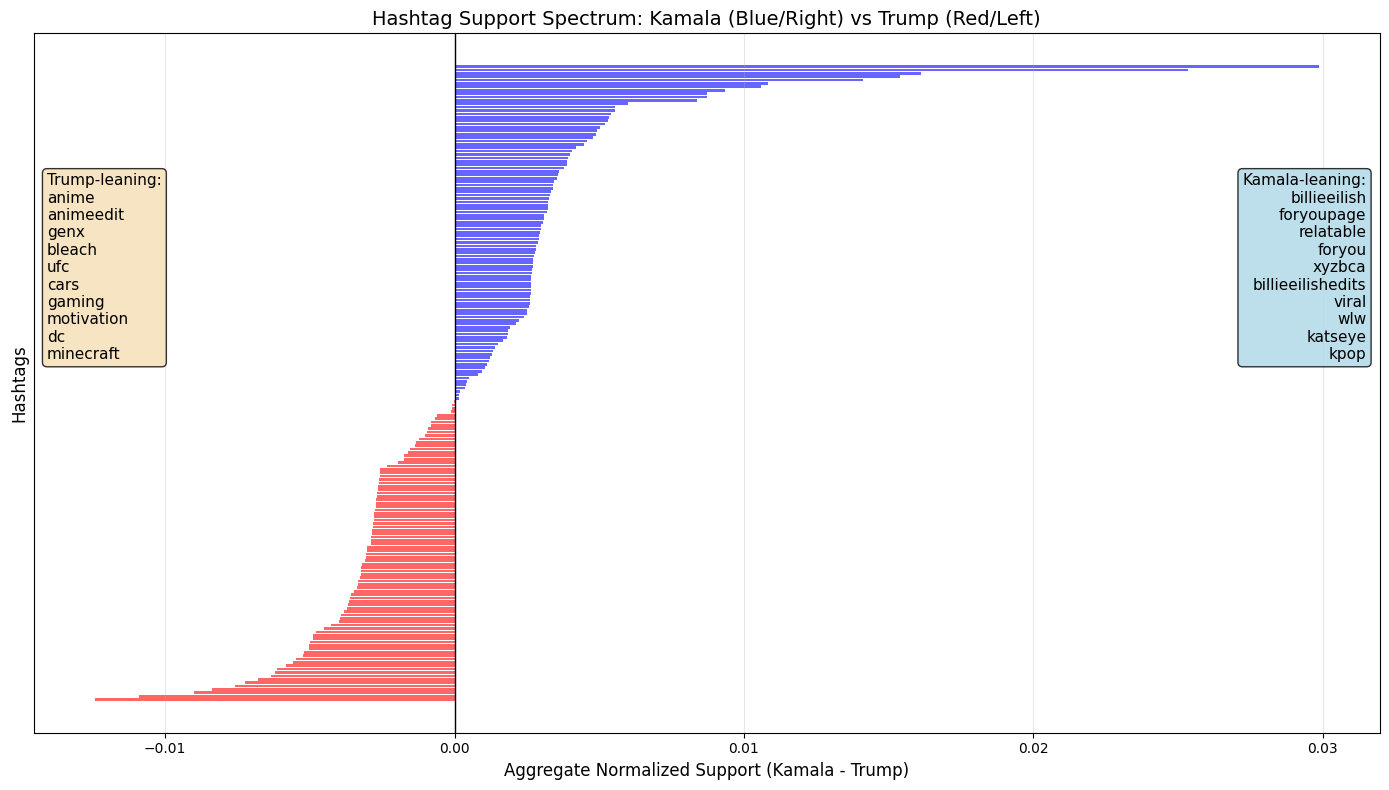

Total unique hashtags: 188

Top 10 Kamala-leaning hashtags:
  billieeilish: 0.0299 (K: 0.0299, T: 0.0000)
  foryoupage: 0.0254 (K: 0.0886, T: 0.0632)
  relatable: 0.0161 (K: 0.0587, T: 0.0426)
  foryou: 0.0154 (K: 0.0856, T: 0.0702)
  xyzbca: 0.0141 (K: 0.0346, T: 0.0205)
  billieeilishedits: 0.0108 (K: 0.0108, T: 0.0000)
  viral: 0.0106 (K: 0.1458, T: 0.1352)
  wlw: 0.0093 (K: 0.0093, T: 0.0000)
  katseye: 0.0087 (K: 0.0087, T: 0.0000)
  kpop: 0.0087 (K: 0.0087, T: 0.0000)

Top 10 Trump-leaning hashtags:
  anime: -0.0124 (K: 0.0081, T: 0.0205)
  animeedit: -0.0109 (K: 0.0000, T: 0.0109)
  genx: -0.0090 (K: 0.0000, T: 0.0090)
  bleach: -0.0084 (K: 0.0000, T: 0.0084)
  ufc: -0.0076 (K: 0.0000, T: 0.0076)
  cars: -0.0072 (K: 0.0000, T: 0.0072)
  gaming: -0.0068 (K: 0.0000, T: 0.0068)
  motivation: -0.0063 (K: 0.0000, T: 0.0063)
  dc: -0.0062 (K: 0.0000, T: 0.0062)
  minecraft: -0.0061 (K: 0.0000, T: 0.0061)


In [47]:
import numpy as np

import matplotlib.pyplot as plt

# Get counts for normalization
k_count = k_df.count()
t_count = t_df.count()

# Calculate normalized support for each singleton
singleton_support = {}

for item, count in Lk_1_kamala.items():
    hashtag = item[0]
    k_norm = count / k_count
    t_norm = Lk_1_trump.get(item, 0) / t_count
    # Aggregate normalized support: positive for kamala, negative for trump
    aggregate = k_norm - t_norm
    singleton_support[hashtag] = {
        'kamala_support': k_norm,
        'trump_support': t_norm,
        'aggregate': aggregate
    }

# Add trump-only singletons
for item, count in Lk_1_trump.items():
    hashtag = item[0]
    if hashtag not in singleton_support:
        t_norm = count / t_count
        aggregate = -t_norm
        singleton_support[hashtag] = {
            'kamala_support': 0,
            'trump_support': t_norm,
            'aggregate': aggregate
        }

# Sort by aggregate support
sorted_items = sorted(singleton_support.items(), key=lambda x: x[1]['aggregate'])

# Create visualization
fig, ax = plt.subplots(figsize=(14, 8))

hashtags = [item[0] for item in sorted_items]
aggregates = [item[1]['aggregate'] for item in sorted_items]

# Color based on which side dominates
colors = ['red' if agg < 0 else 'blue' for agg in aggregates]

# Create bar chart
bars = ax.barh(range(len(hashtags)), aggregates, color=colors, alpha=0.6)
ax.set_yticks(range(len(hashtags)))
ax.set_yticklabels(hashtags, fontsize=9)

# Identify top 10 on each side
top_10_trump = set(range(10))  # Leftmost 10 (Trump)
top_10_kamala = set(range(len(hashtags) - 10, len(hashtags)))  # Rightmost 10 (Kamala)
label_indices = top_10_trump | top_10_kamala


# Left side (Trump) - top 10 terms
left_labels = [hashtags[i] for i in sorted(top_10_trump)]
left_text = "Trump-leaning:\n" + "\n".join(left_labels)

# Right side (Kamala) - top 10 terms
right_labels = [hashtags[i] for i in sorted(top_10_kamala, reverse=True)]
right_text = "Kamala-leaning:\n" + "\n".join(right_labels)

# Add text boxes to the left and right of the plot
ax.text(0.01, 0.8, left_text, transform=ax.transAxes, fontsize=11,
    verticalalignment='top', horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.text(0.99, 0.8, right_text, transform=ax.transAxes, fontsize=11,
    verticalalignment='top', horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Aggregate Normalized Support (Kamala - Trump)', fontsize=12)
ax.set_ylabel('Hashtags', fontsize=12)
ax.set_title('Hashtag Support Spectrum: Kamala (Blue/Right) vs Trump (Red/Left)', fontsize=14)
ax.set_yticks([])
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total unique hashtags: {len(singleton_support)}")
print(f"\nTop 10 Kamala-leaning hashtags:")
for i in range(min(10, len(sorted_items))):
    idx = -(i+1)
    hashtag, data = sorted_items[idx]
    print(f"  {hashtag}: {data['aggregate']:.4f} (K: {data['kamala_support']:.4f}, T: {data['trump_support']:.4f})")

print(f"\nTop 10 Trump-leaning hashtags:")
for i in range(min(10, len(sorted_items))):
    hashtag, data = sorted_items[i]
    print(f"  {hashtag}: {data['aggregate']:.4f} (K: {data['kamala_support']:.4f}, T: {data['trump_support']:.4f})")

In [ ]:
# Ensure each clean_hash array contains only unique hashtags
k_df = k_df.withColumn("clean_hash", F.array_distinct(F.col("clean_hash")))
t_df = t_df.withColumn("clean_hash", F.array_distinct(F.col("clean_hash")))

In [ ]:
from pyspark.ml.fpm import FPGrowth

# FPGrowth requires the input column to be named 'items'

# Before running cell again: check to make sure all hashes are unique sets


fp_growth_k = FPGrowth(itemsCol="clean_hash", minSupport=(s_kamala / k_df.count()), minConfidence=0.8)
model_k = fp_growth_k.fit(k_df)

# Display frequent itemsets

print("Frequent Itemsets found by FP-Growth:")
model_k.freqItemsets.sort("freq", ascending=False).show()

# Display generated association rules
print("Association Rules found by FP-Growth:")
model_k.associationRules.sort("confidence", ascending=False).show()

26/01/16 17:24:17 WARN TaskSetManager: Stage 43 contains a task of very large size (1263 KiB). The maximum recommended task size is 1000 KiB.
26/01/16 17:24:18 WARN TaskSetManager: Stage 46 contains a task of very large size (1263 KiB). The maximum recommended task size is 1000 KiB.
26/01/16 17:24:20 WARN TaskSetManager: Stage 47 contains a task of very large size (1263 KiB). The maximum recommended task size is 1000 KiB.
26/01/16 17:24:20 WARN TaskSetManager: Stage 48 contains a task of very large size (1263 KiB). The maximum recommended task size is 1000 KiB.


Frequent Itemsets found by FP-Growth:


26/01/16 17:24:21 WARN TaskSetManager: Stage 50 contains a task of very large size (1263 KiB). The maximum recommended task size is 1000 KiB.


+--------------------+-----+
|               items| freq|
+--------------------+-----+
|             [viral]|72227|
|        [foryoupage]|44321|
|            [foryou]|43589|
|         [relatable]|29637|
|              [edit]|28175|
|             [funny]|19896|
|      [billieeilish]|18045|
|            [xyzbca]|17401|
|          [trending]|16524|
|     [foryou, viral]|14818|
|[foryou, foryoupage]|14660|
| [foryoupage, viral]|14528|
|          [fypviral]|13336|
|                [fy]|10950|
|              [real]| 9462|
|[fypppppppppppppp...| 9450|
|             [trend]| 9080|
|  [relatable, viral]| 8670|
|    [strangerthings]| 8548|
|       [edit, viral]| 8543|
+--------------------+-----+
only showing top 20 rows

Association Rules found by FP-Growth:
+--------------------+--------------+------------------+------------------+--------------------+
|          antecedent|    consequent|        confidence|              lift|             support|
+--------------------+--------------+---------

In [ ]:
fp_growth_t = FPGrowth(itemsCol="clean_hash", minSupport=(s_trump / t_df.count()), minConfidence=0.8)
model_t = fp_growth_t.fit(t_df)

# Display frequent itemsets

print("Frequent Itemsets found by FP-Growth:")
model_t.freqItemsets.sort("freq", ascending=False).show()

# Display generated association rules
print("Association Rules found by FP-Growth:")
model_t.associationRules.sort("confidence", ascending=False).show()

26/01/16 17:25:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:25:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:25:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:25:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/01/16 17:25:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Frequent Itemsets found by FP-Growth:
+--------------------+-----+
|               items| freq|
+--------------------+-----+
|             [viral]|16033|
|            [foryou]| 7807|
|        [foryoupage]| 7074|
|              [edit]| 6509|
|         [relatable]| 5502|
|             [funny]| 4084|
|          [trending]| 3065|
|              [real]| 2759|
|     [foryou, viral]| 2605|
|            [xyzbca]| 2516|
|                [fy]| 2384|
|          [fypviral]| 2334|
| [foryoupage, viral]| 2310|
|[foryoupage, foryou]| 2204|
|              [meme]| 1943|
|       [edit, viral]| 1737|
|        [blowthisup]| 1665|
|            [capcut]| 1630|
|  [relatable, viral]| 1626|
|        [viralvideo]| 1599|
+--------------------+-----+
only showing top 20 rows

Association Rules found by FP-Growth:
+--------------+----------+------------------+------------------+--------------------+
|    antecedent|consequent|        confidence|              lift|             support|
+--------------+----------+-

26/01/16 18:09:16 WARN TaskSetManager: Stage 256 contains a task of very large size (1758 KiB). The maximum recommended task size is 1000 KiB.


       Metric            Kamala             Trump
   Total Sets            721794            172400
 Total Tokens           3210963            716774
Unique Tokens            317452            120509
  Top 1 Token     viral: 105241      viral: 23311
  Top 2 Token foryoupage: 63916     foryou: 12105
  Top 3 Token     foryou: 61782 foryoupage: 10895
  Top 4 Token  relatable: 42341       edit: 10359
  Top 5 Token       edit: 41038   relatable: 7337


            Metric            Kamala             Trump
        Total Sets            721794            172400
      Total Tokens           3210963            716774
     Unique Tokens            317452            120509
Average Set Length              4.45              4.16
       Top 1 Token     viral: 105241      viral: 23311
       Top 2 Token foryoupage: 63916     foryou: 12105
       Top 3 Token     foryou: 61782 foryoupage: 10895
       Top 4 Token  relatable: 42341       edit: 10359
       Top 5 Token       edit: 41038   relatable: 7337


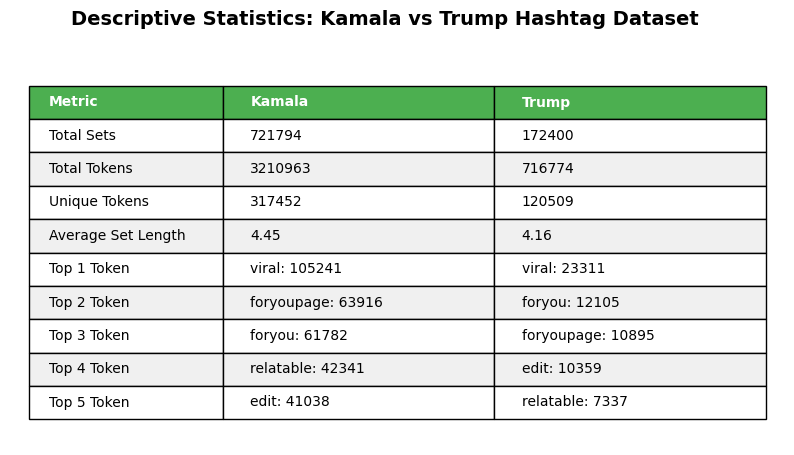

In [53]:
import pandas as pd

# Calculate statistics for k_df
k_total_sets = k_df.count()
k_total_tokens = k_df.rdd.flatMap(lambda row: row.clean_hash).count()
k_unique_tokens = k_df.rdd.flatMap(lambda row: row.clean_hash).distinct().count()
k_top_5 = sorted(Lk_1_kamala.items(), key=lambda x: x[1], reverse=True)[:5]

# Calculate statistics for t_df
t_total_sets = t_df.count()
t_total_tokens = t_df.rdd.flatMap(lambda row: row.clean_hash).count()
t_unique_tokens = t_df.rdd.flatMap(lambda row: row.clean_hash).distinct().count()
t_top_5 = sorted(Lk_1_trump.items(), key=lambda x: x[1], reverse=True)[:5]

# Create summary table
stats_data = {
    'Metric': [
        'Total Sets',
        'Total Tokens',
        'Unique Tokens',
        'Top 1 Token',
        'Top 2 Token',
        'Top 3 Token',
        'Top 4 Token',
        'Top 5 Token'
    ],
    'Kamala': [
        k_total_sets,
        k_total_tokens,
        k_unique_tokens,
        f"{k_top_5[0][0][0]}: {k_top_5[0][1]}",
        f"{k_top_5[1][0][0]}: {k_top_5[1][1]}",
        f"{k_top_5[2][0][0]}: {k_top_5[2][1]}",
        f"{k_top_5[3][0][0]}: {k_top_5[3][1]}",
        f"{k_top_5[4][0][0]}: {k_top_5[4][1]}"
    ],
    'Trump': [
        t_total_sets,
        t_total_tokens,
        t_unique_tokens,
        f"{t_top_5[0][0][0]}: {t_top_5[0][1]}",
        f"{t_top_5[1][0][0]}: {t_top_5[1][1]}",
        f"{t_top_5[2][0][0]}: {t_top_5[2][1]}",
        f"{t_top_5[3][0][0]}: {t_top_5[3][1]}",
        f"{t_top_5[4][0][0]}: {t_top_5[4][1]}"
    ]
}

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))
# Calculate average set length
k_avg_length = k_df.rdd.map(lambda row: len(row.clean_hash)).mean()
t_avg_length = t_df.rdd.map(lambda row: len(row.clean_hash)).mean()

# Add to stats_data
stats_data['Metric'].insert(3, 'Average Set Length')
stats_data['Kamala'].insert(3, f"{k_avg_length:.2f}")
stats_data['Trump'].insert(3, f"{t_avg_length:.2f}")

stats_df = pd.DataFrame(stats_data)
print(stats_df.to_string(index=False))

# Convert table to image
import matplotlib.pyplot as plt
from matplotlib.table import Table

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=stats_df.values, colLabels=stats_df.columns, 
                 cellLoc='center', loc='center', colWidths=[0.25, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(len(stats_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(stats_df) + 1):
    for j in range(len(stats_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.savefig('viz/descriptive_statistics_table.png', dpi=150, bbox_inches='tight')

# Add title
fig.suptitle('Descriptive Statistics: Kamala vs Trump Hashtag Dataset', fontsize=14, fontweight='bold', y=0.98)

# Left justify text in cells
for i in range(len(stats_df) + 1):
    for j in range(len(stats_df.columns)):
        table[(i, j)].set_text_props(ha='left')
plt.show()

In [ ]:
conn.close()